In [1]:
import uproot
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import ROOT
import awkward as ak
from yaml import safe_load
from math import sqrt

Welcome to JupyROOT 6.28/10


In [2]:
# Config and yaml file must be in this directory by default
# Absolute path must be supplied for the script to work in batch mode
configPath =  "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/"
sys.path.append(os.path.abspath(configPath))
import config as cfg

## Look at correlations - Currently old data as current data still processing (with correct BSC)


n.b. for old_and_incorrectBSC added extra variables whilst still processing ud so some ud files have extra variables -> cant compile ud into one file

## Set up for full data

In [7]:
# Read list of feature names used in the BDT from the config YAML file
with open(cfg.fccana_opts['yamlPath']) as stream:
    yaml = safe_load(stream)
    BDThbranchList = yaml['BDTh-vars']

In [9]:
print(len(BDThbranchList))
BDThbranchList

55


['EVT_Thrust_mag',
 'EVT_unitThrust_x',
 'EVT_unitThrust_y',
 'EVT_unitThrust_z',
 'EVT_Thrust_deltaE',
 'EVT_hemisEmin_e',
 'EVT_hemisEmin_eCharged',
 'EVT_hemisEmin_eNeutral',
 'EVT_hemisEmin_n',
 'EVT_hemisEmin_nCharged',
 'EVT_hemisEmin_nNeutral',
 'EVT_hemisEmin_nDV',
 'EVT_hemisEmax_e',
 'EVT_hemisEmax_eCharged',
 'EVT_hemisEmax_eNeutral',
 'EVT_hemisEmax_n',
 'EVT_hemisEmax_nCharged',
 'EVT_hemisEmax_nNeutral',
 'Rec_track_n',
 'Rec_PV_ntracks',
 'Rec_vtx_n',
 'Rec_PV_x',
 'Rec_PV_y',
 'Rec_PV_z',
 'EVT_e',
 'EVT_p',
 'EVT_sum_Rec_px',
 'EVT_sum_Rec_py',
 'EVT_sum_Rec_pz',
 'EVT_hemisEmin_maxpChargedRP_px',
 'EVT_hemisEmin_maxpChargedRP_py',
 'EVT_hemisEmin_maxpChargedRP_pz',
 'EVT_hemisEmin_sum_Rec_vtx_ntracks_exclPV',
 'Rec_vtx_ntracks_max_hemisEmin',
 'Rec_vtx_d2PV_max_hemisEmin',
 'Rec_track_absd0chi2_max_hemisEmin',
 'Rec_track_absz0chi2_max_hemisEmin',
 'Rec_track_absz0chi2_min_hemisEmin',
 'Rec_track_absd0_min_hemisEmin',
 'EVT_hemisEmin_maxpChargedRP_p',
 'EVT_hemisEmin_

In [13]:
folder_path = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDThbranchList


df_Bs_chunk0 = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

In [14]:
df_Bs_chunk0

,EVT_Thrust_mag,EVT_unitThrust_x,EVT_unitThrust_y,EVT_unitThrust_z,EVT_Thrust_deltaE,EVT_hemisEmin_e,EVT_hemisEmin_eCharged,EVT_hemisEmin_eNeutral,EVT_hemisEmin_n,EVT_hemisEmin_nCharged,...,EVT_hemisEmax_maxpChargedRP_fromPV,EVT_hemisEmax_nDV,EVT_hemisEmax_sum_Rec_vtx_ntracks_exclPV,Rec_vtx_ntracks_max_hemisEmax,Rec_vtx_thrustCosTheta_max_hemisEmax,Rec_thrustCosTheta_ave_hemisEmax,Rec_vtx_d2PV_max_hemisEmax,Rec_vtx_d2PV_min_hemisEmax,Rec_track_absd0chi2_max_hemisEmax,Rec_track_absz0_max_hemisEmax
0,0.956780,-0.584299,-0.641939,-0.496496,28.722198,12.269582,10.839794,1.429788,6.0,3.0,...,0,3.0,10.0,5.0,-0.964074,-0.909592,274.838959,2.136631,264.339050,55.531818
1,0.951441,0.278872,0.206116,0.937948,4.833950,35.190300,22.606085,12.584213,31.0,14.0,...,0,2.0,8.0,5.0,-0.997422,-0.945258,2.705372,0.534272,5.295071,1.150440
2,0.966045,-0.892128,0.445022,0.077861,40.687138,4.425723,3.060864,1.364859,6.0,3.0,...,0,2.0,6.0,3.0,-0.990998,-0.904073,0.574332,0.469254,6.422502,0.629745
3,0.883285,-0.901217,-0.111468,-0.418787,33.105560,12.046289,4.866982,7.179308,14.0,5.0,...,1,1.0,2.0,2.0,-0.993373,-0.797493,0.305787,0.305787,1.696127,0.472537
4,0.952900,0.439443,-0.847875,-0.296646,40.880516,5.112665,0.773938,4.338727,9.0,1.0,...,0,3.0,8.0,4.0,-0.966846,-0.886590,4.369824,2.773775,43.880478,1.025543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182286,0.911895,-0.519610,0.569528,0.636901,25.742987,14.006952,10.421866,3.585086,16.0,8.0,...,0,3.0,7.0,3.0,-0.996897,-0.809534,361.444031,14.562974,73.878235,11.977011
182287,0.832273,0.942566,0.160815,0.292759,7.461573,17.765160,9.985227,7.779932,27.0,10.0,...,-999,1.0,2.0,2.0,-0.988159,-0.727451,17.823734,17.823734,138.544846,1.046300
182288,0.912764,0.330349,0.613388,-0.717373,42.110199,5.146344,2.879112,2.267231,8.0,3.0,...,0,1.0,4.0,4.0,-0.997046,-0.869282,0.524644,0.524644,6.305610,0.319229
182289,0.960667,0.168175,-0.499112,-0.850061,36.741703,6.571060,3.335303,3.235757,6.0,2.0,...,1,0.0,0.0,0.0,0.000000,-0.937649,0.000000,0.000000,43.259674,1.744972


Text(0.5, 1.0, 'Bs Correlation Matrix')

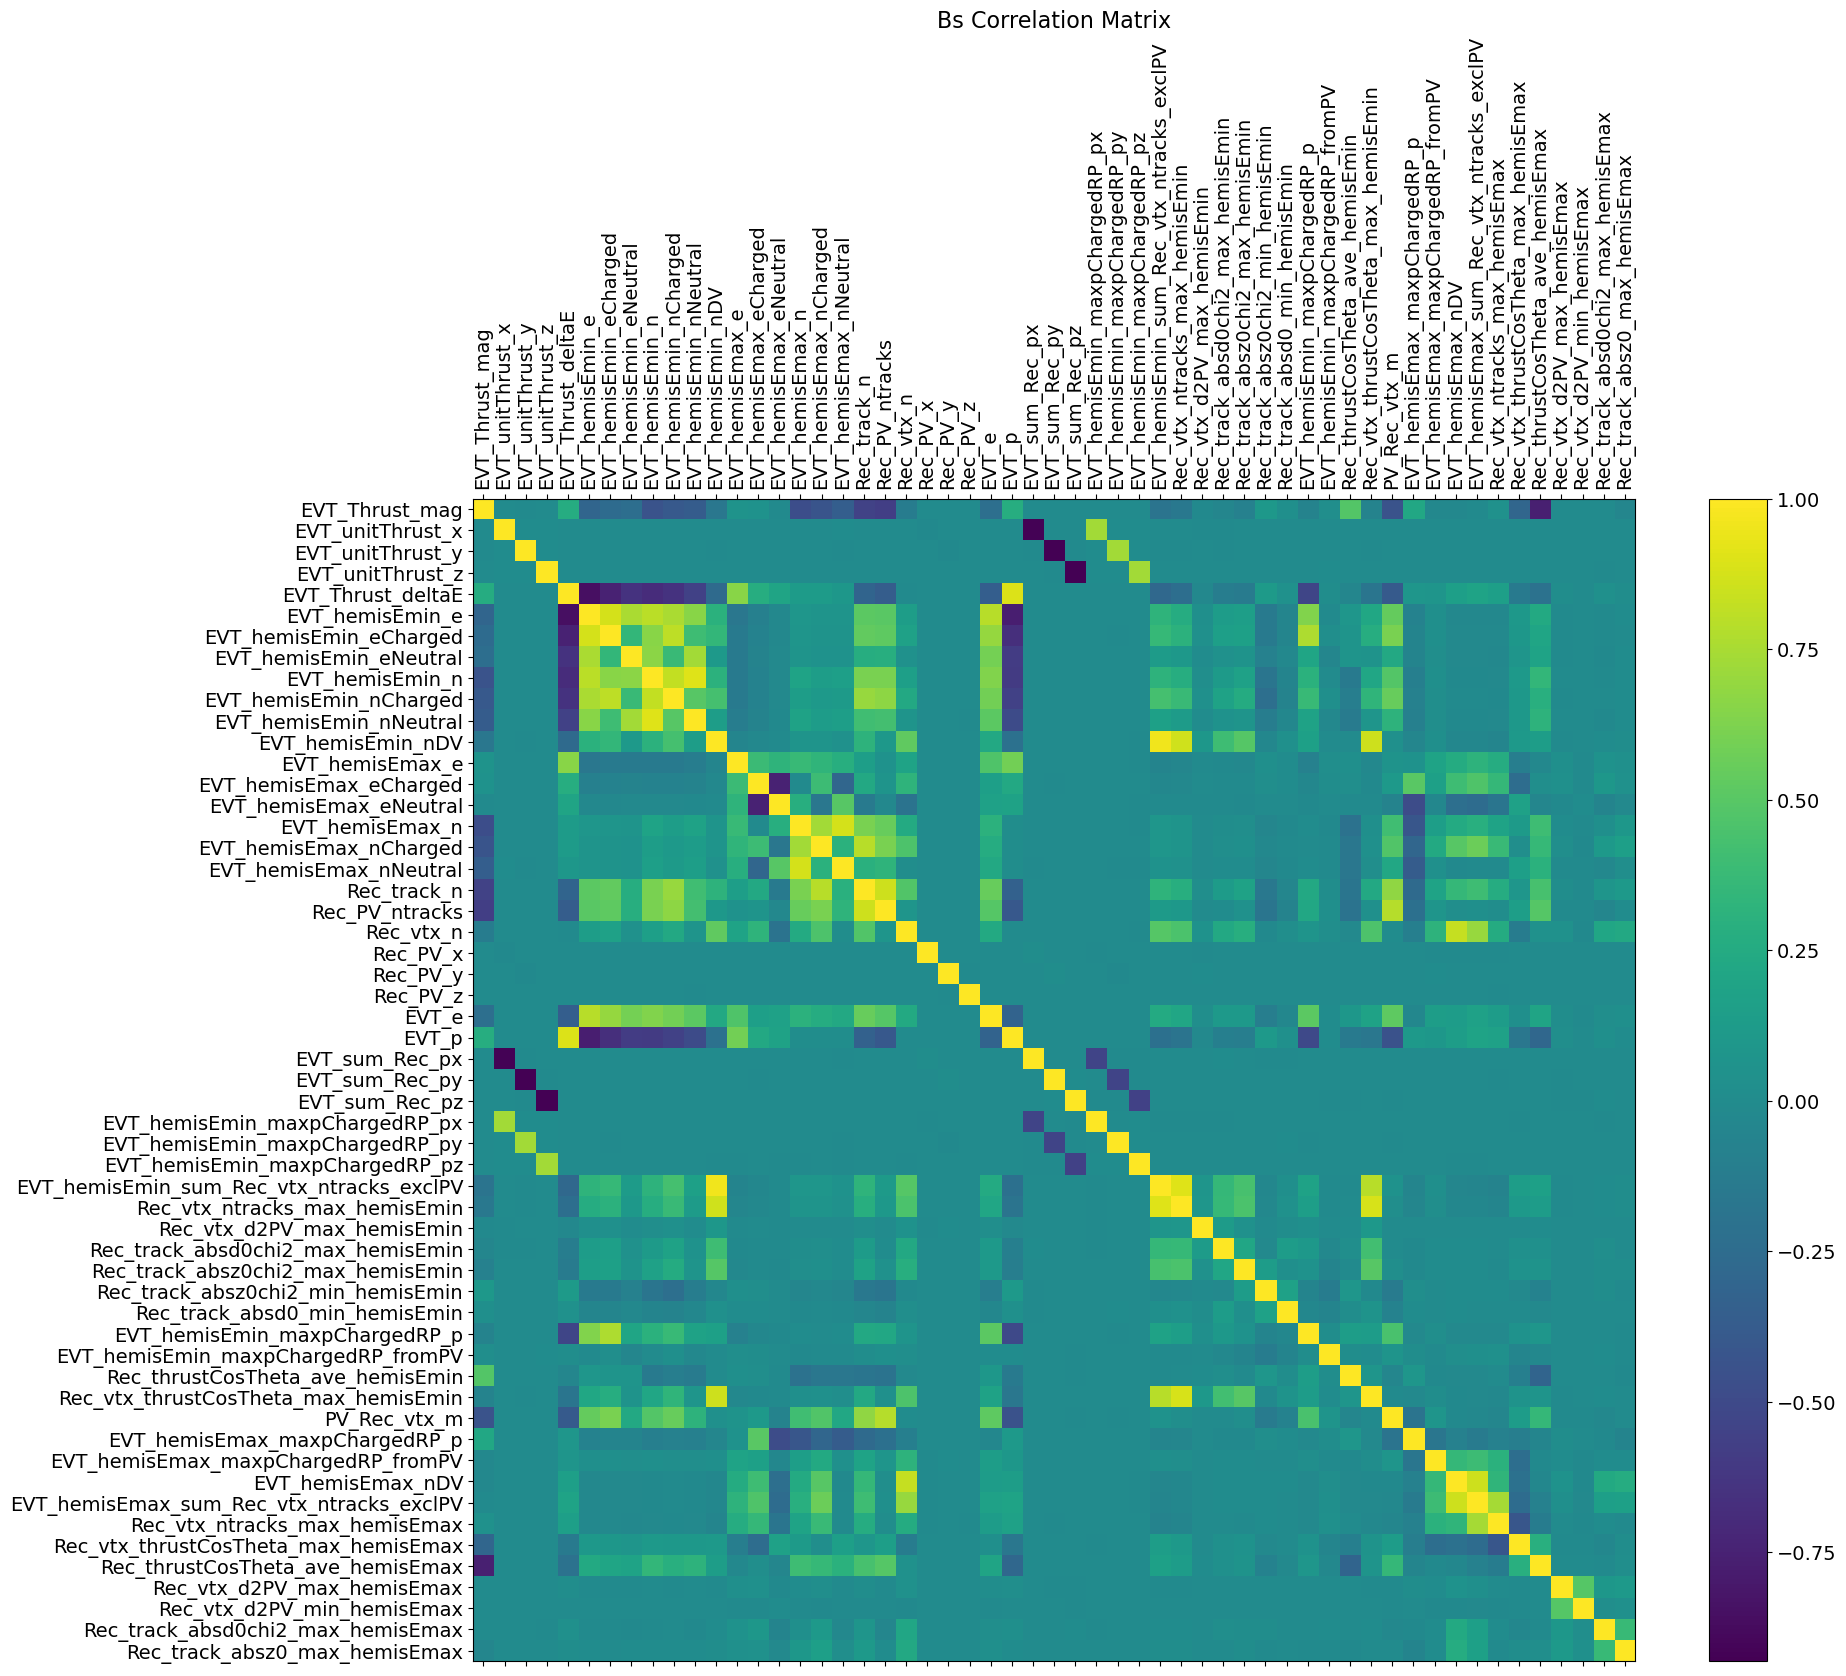

In [15]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
Bs_correlation_matrix = df_Bs_chunk0.corr()
plt.matshow(Bs_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_Bs_chunk0.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Bs Correlation Matrix', fontsize=16)

## Repeat for one hadronic background and taus

### Zud

In [17]:
sample = 'p8_ee_Zud_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDThbranchList


df_ud = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

    
# close file
uproot_file.close()



Text(0.5, 1.0, 'Zud Correlation Matrix')

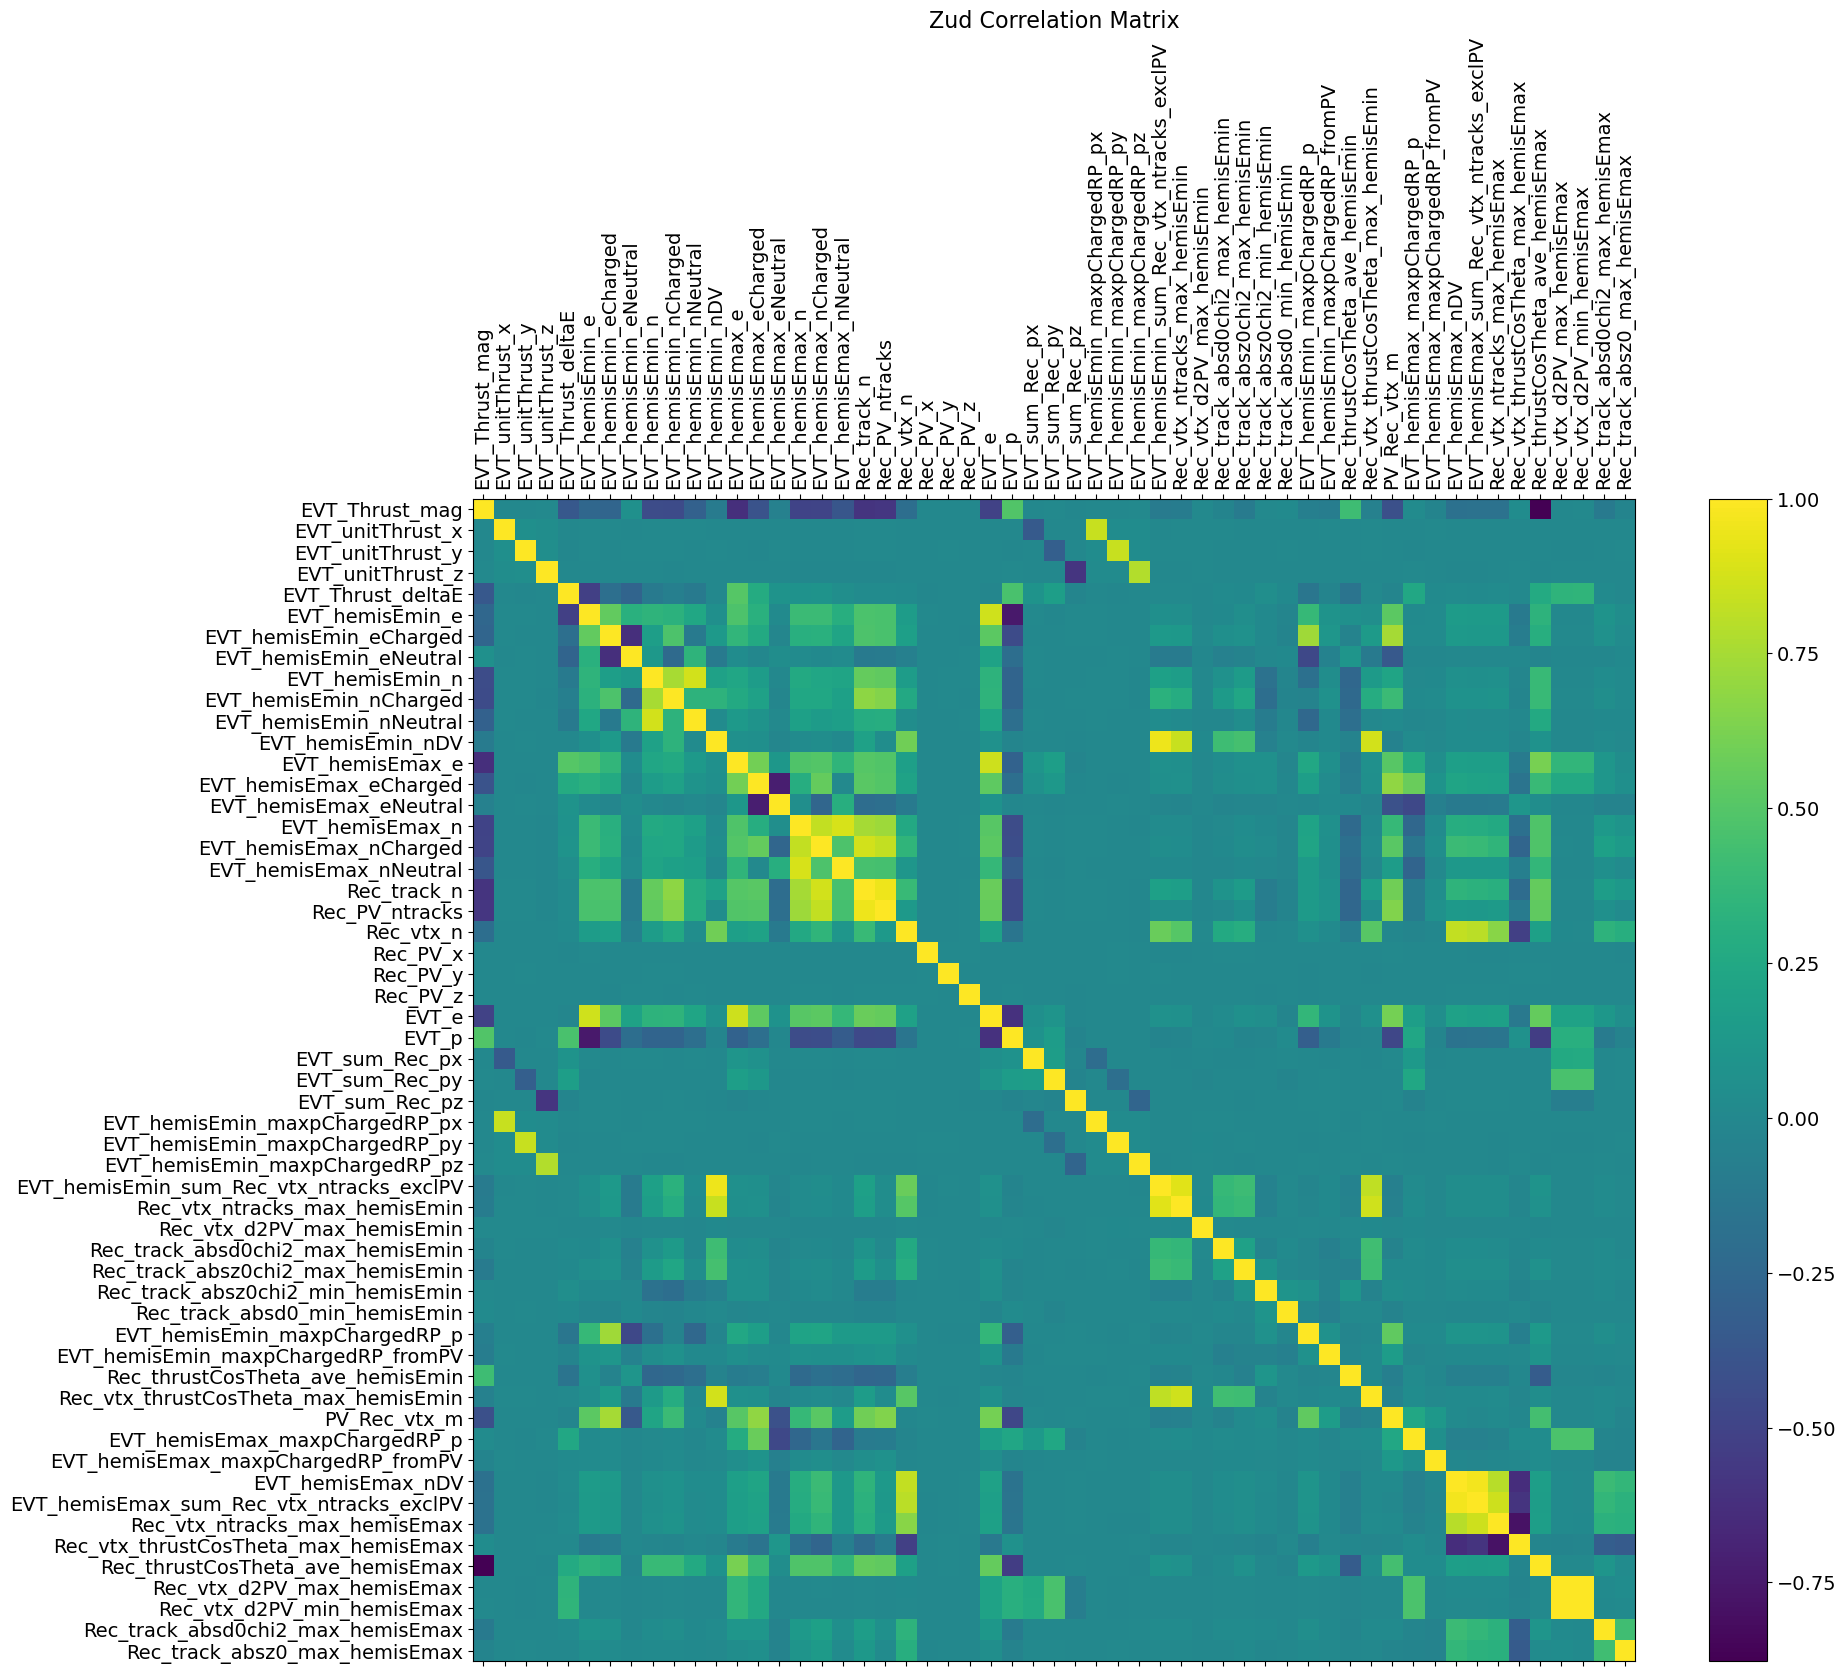

In [18]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
ud_correlation_matrix = df_ud.corr()
plt.matshow(ud_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Zud Correlation Matrix', fontsize=16)

Text(0.5, 1.0, 'Difference in Bs and Zud Correlation Matrix')

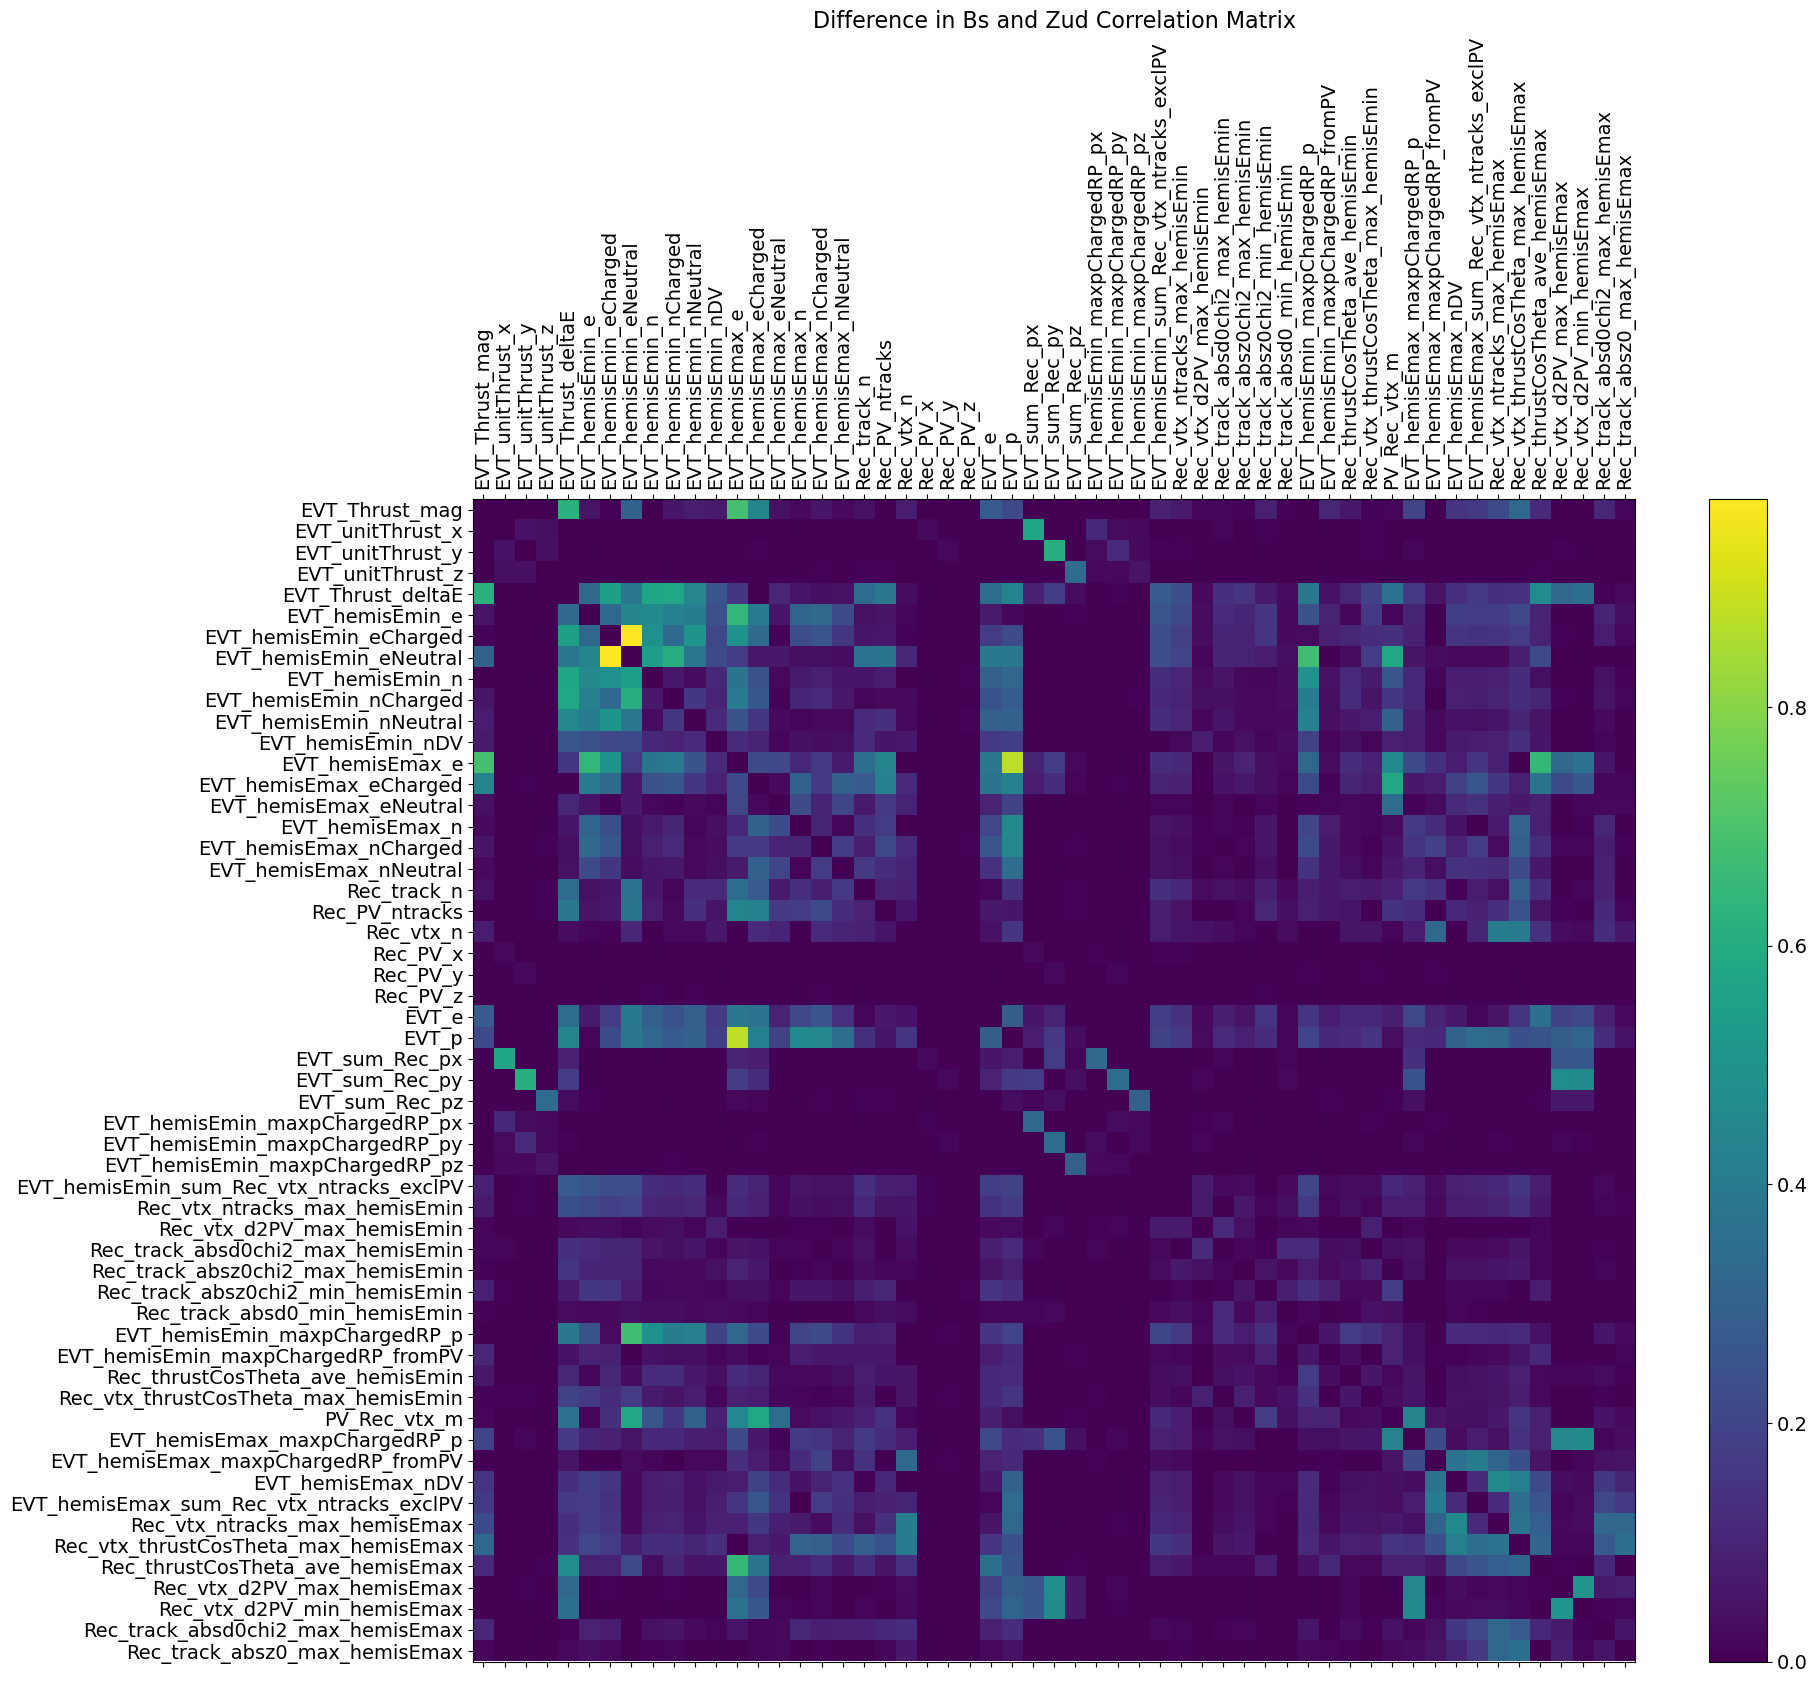

In [19]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
differenece_corr_matrix_Bsud = abs( Bs_correlation_matrix - ud_correlation_matrix)
plt.matshow(differenece_corr_matrix_Bsud, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Difference in Bs and Zud Correlation Matrix', fontsize=16)

### Zbb

In [20]:
sample = 'p8_ee_Zbb_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDThbranchList


df_bb= tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

# close file
uproot_file.close()



Text(0.5, 1.0, 'Zbb Correlation Matrix')

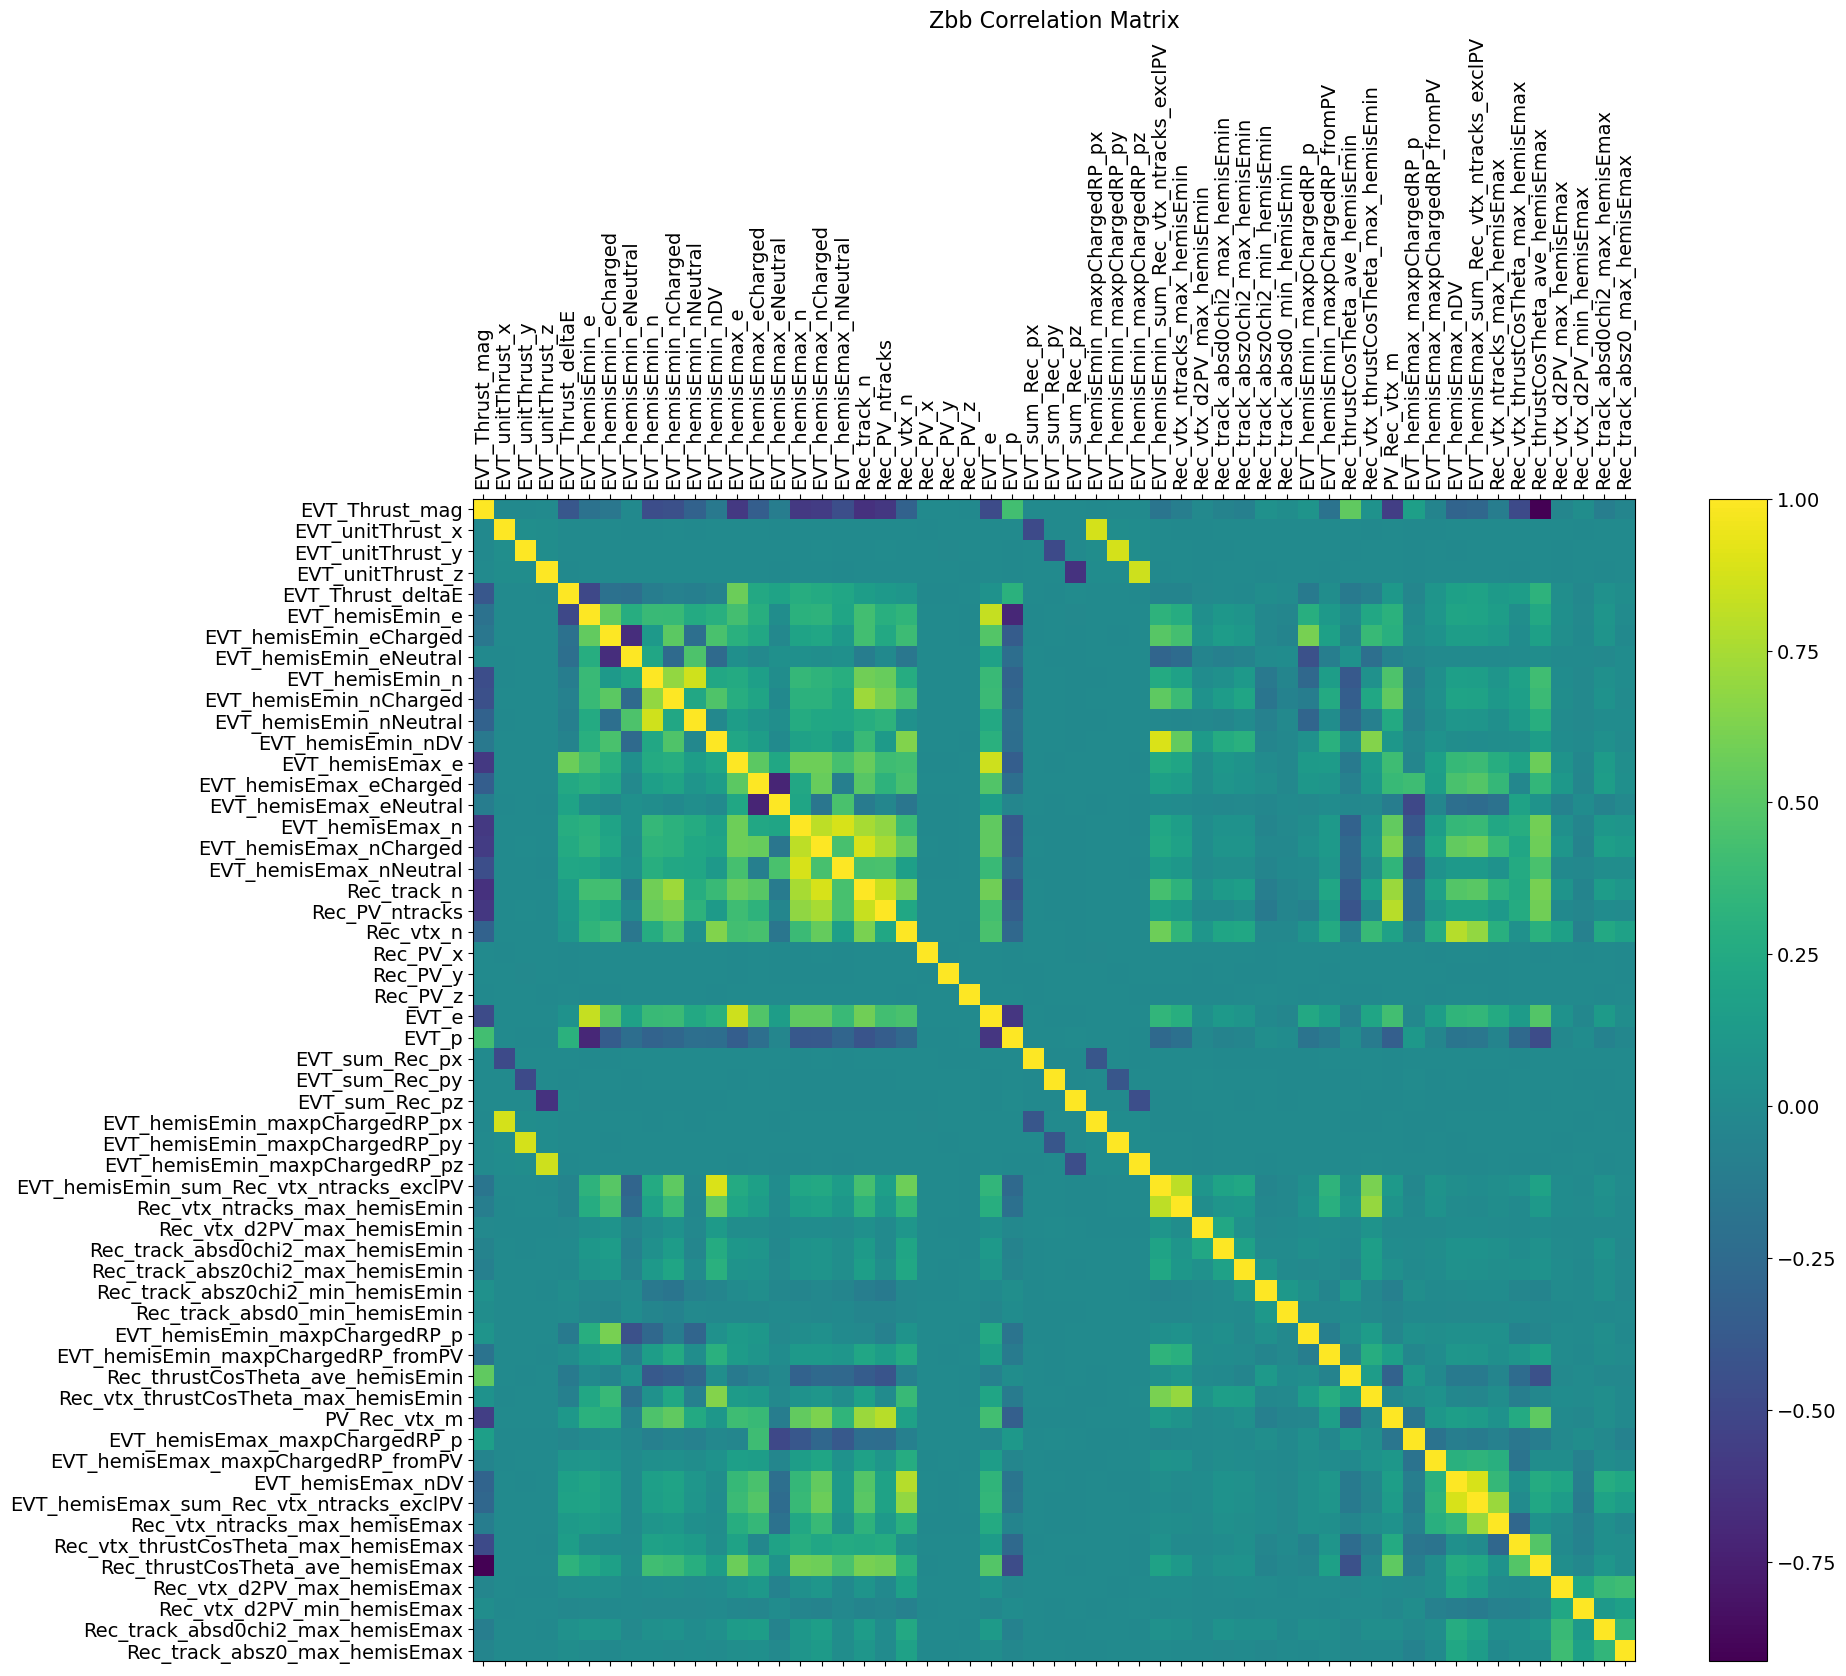

In [21]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
bb_correlation_matrix = df_bb.corr()
plt.matshow(bb_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_bb.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Zbb Correlation Matrix', fontsize=16)

Text(0.5, 1.0, 'Difference in Bs and Zbb Correlation Matrix')

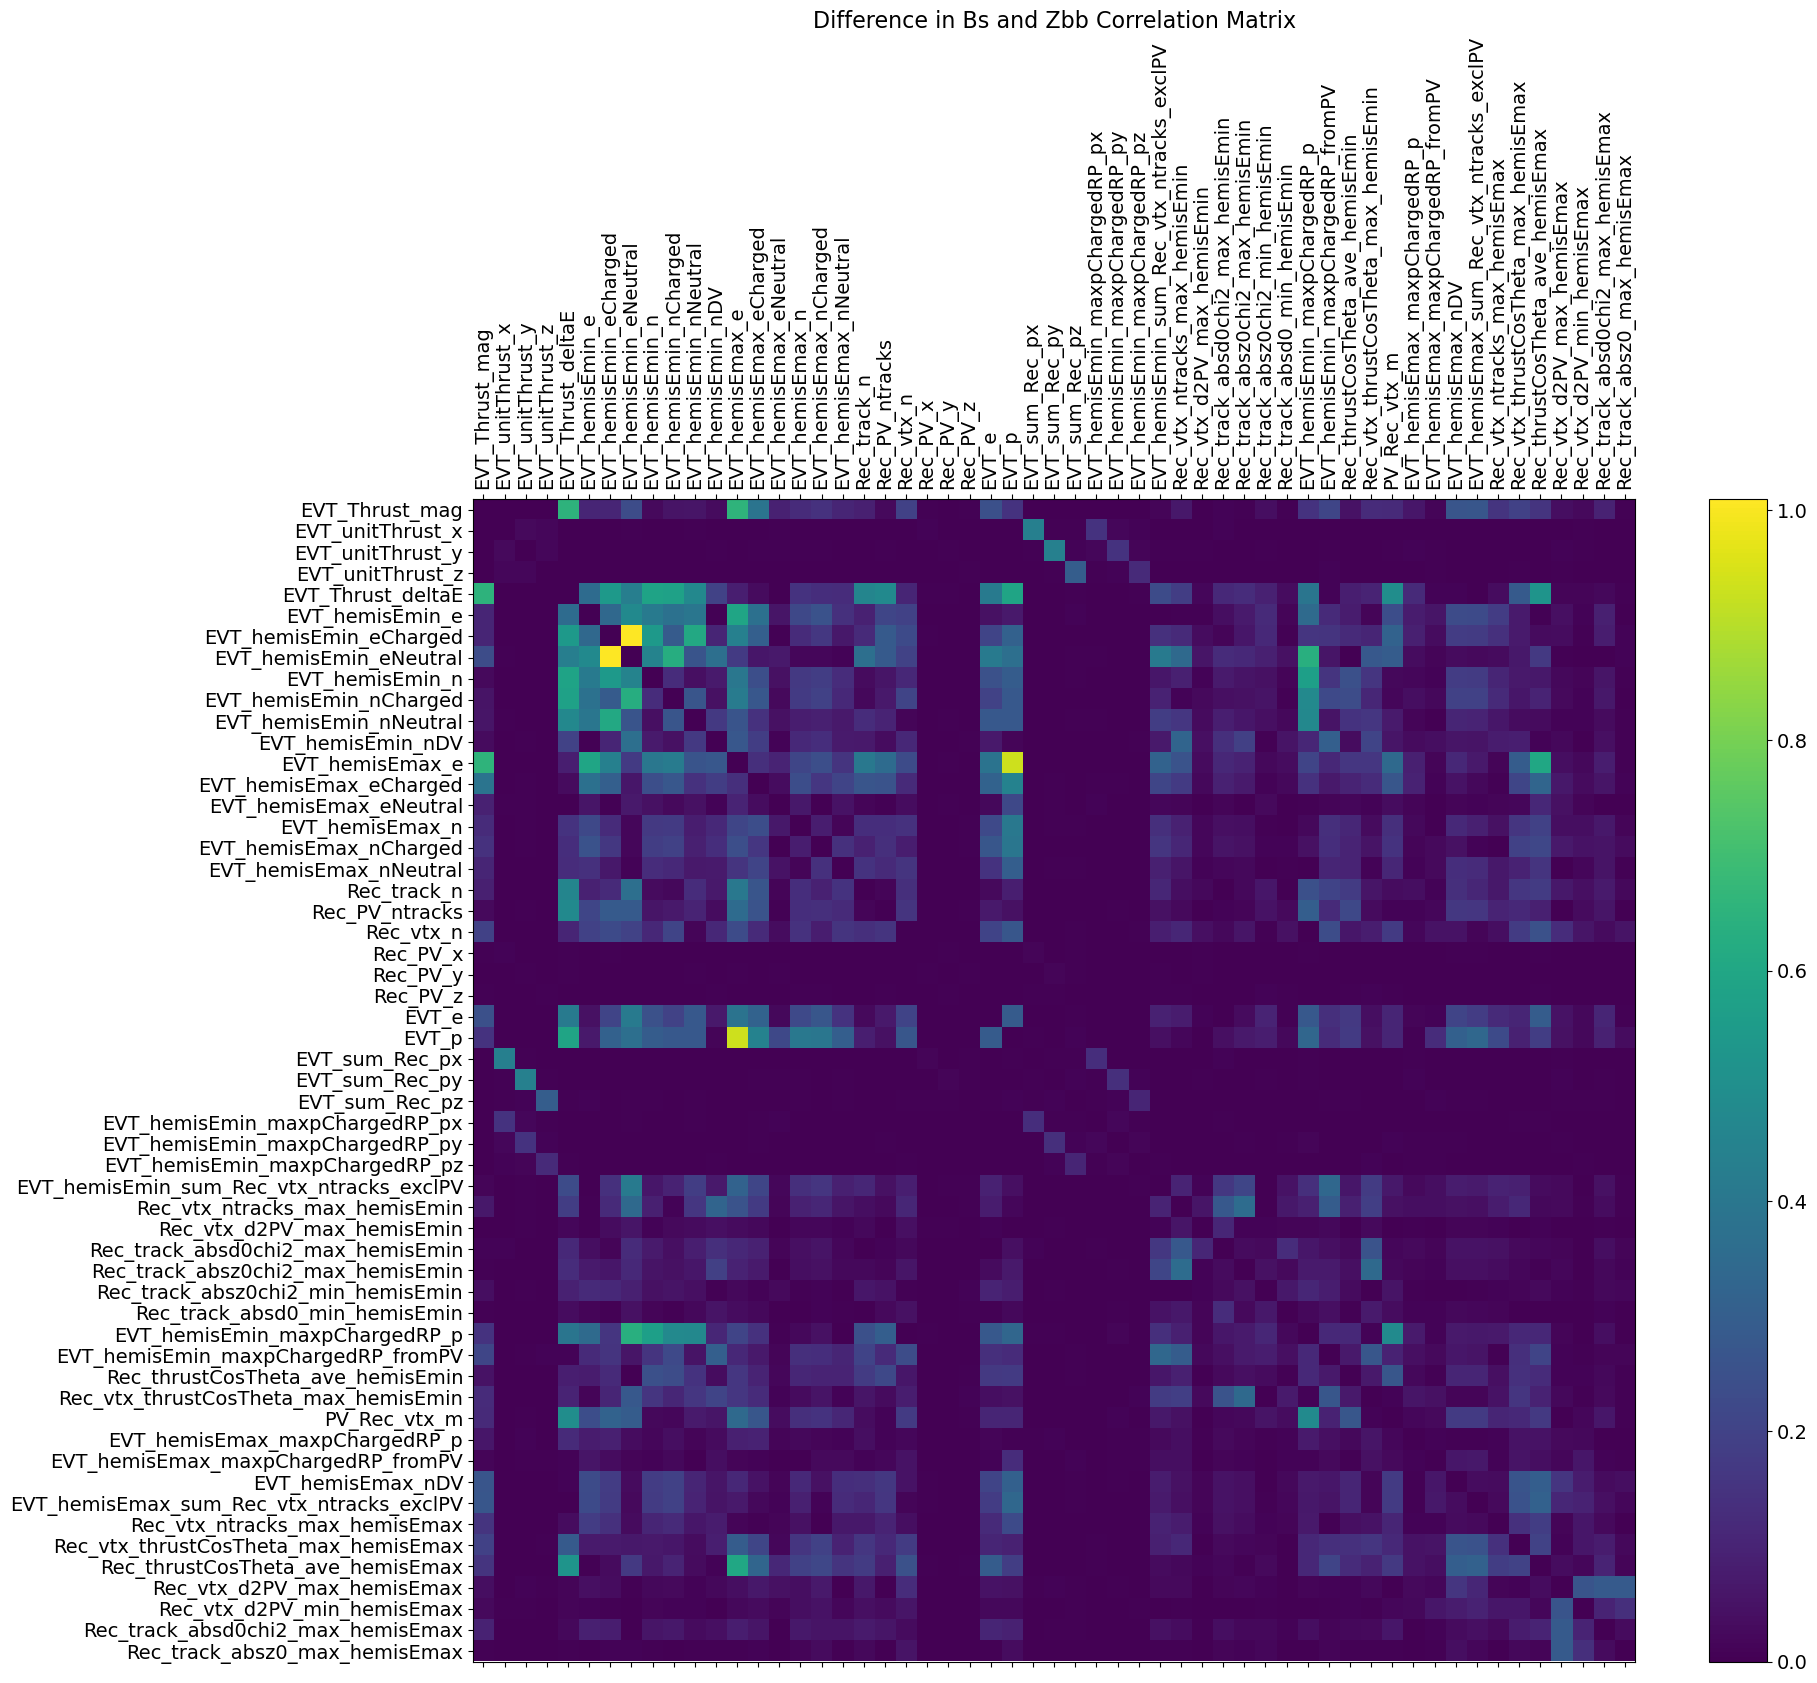

In [24]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
differenece_corr_matrix_Bsbb = abs( Bs_correlation_matrix - bb_correlation_matrix)
plt.matshow(differenece_corr_matrix_Bsbb, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Difference in Bs and Zbb Correlation Matrix', fontsize=16)

Text(0.5, 1.0, 'Difference in Zbb and Zud Correlation Matrix')

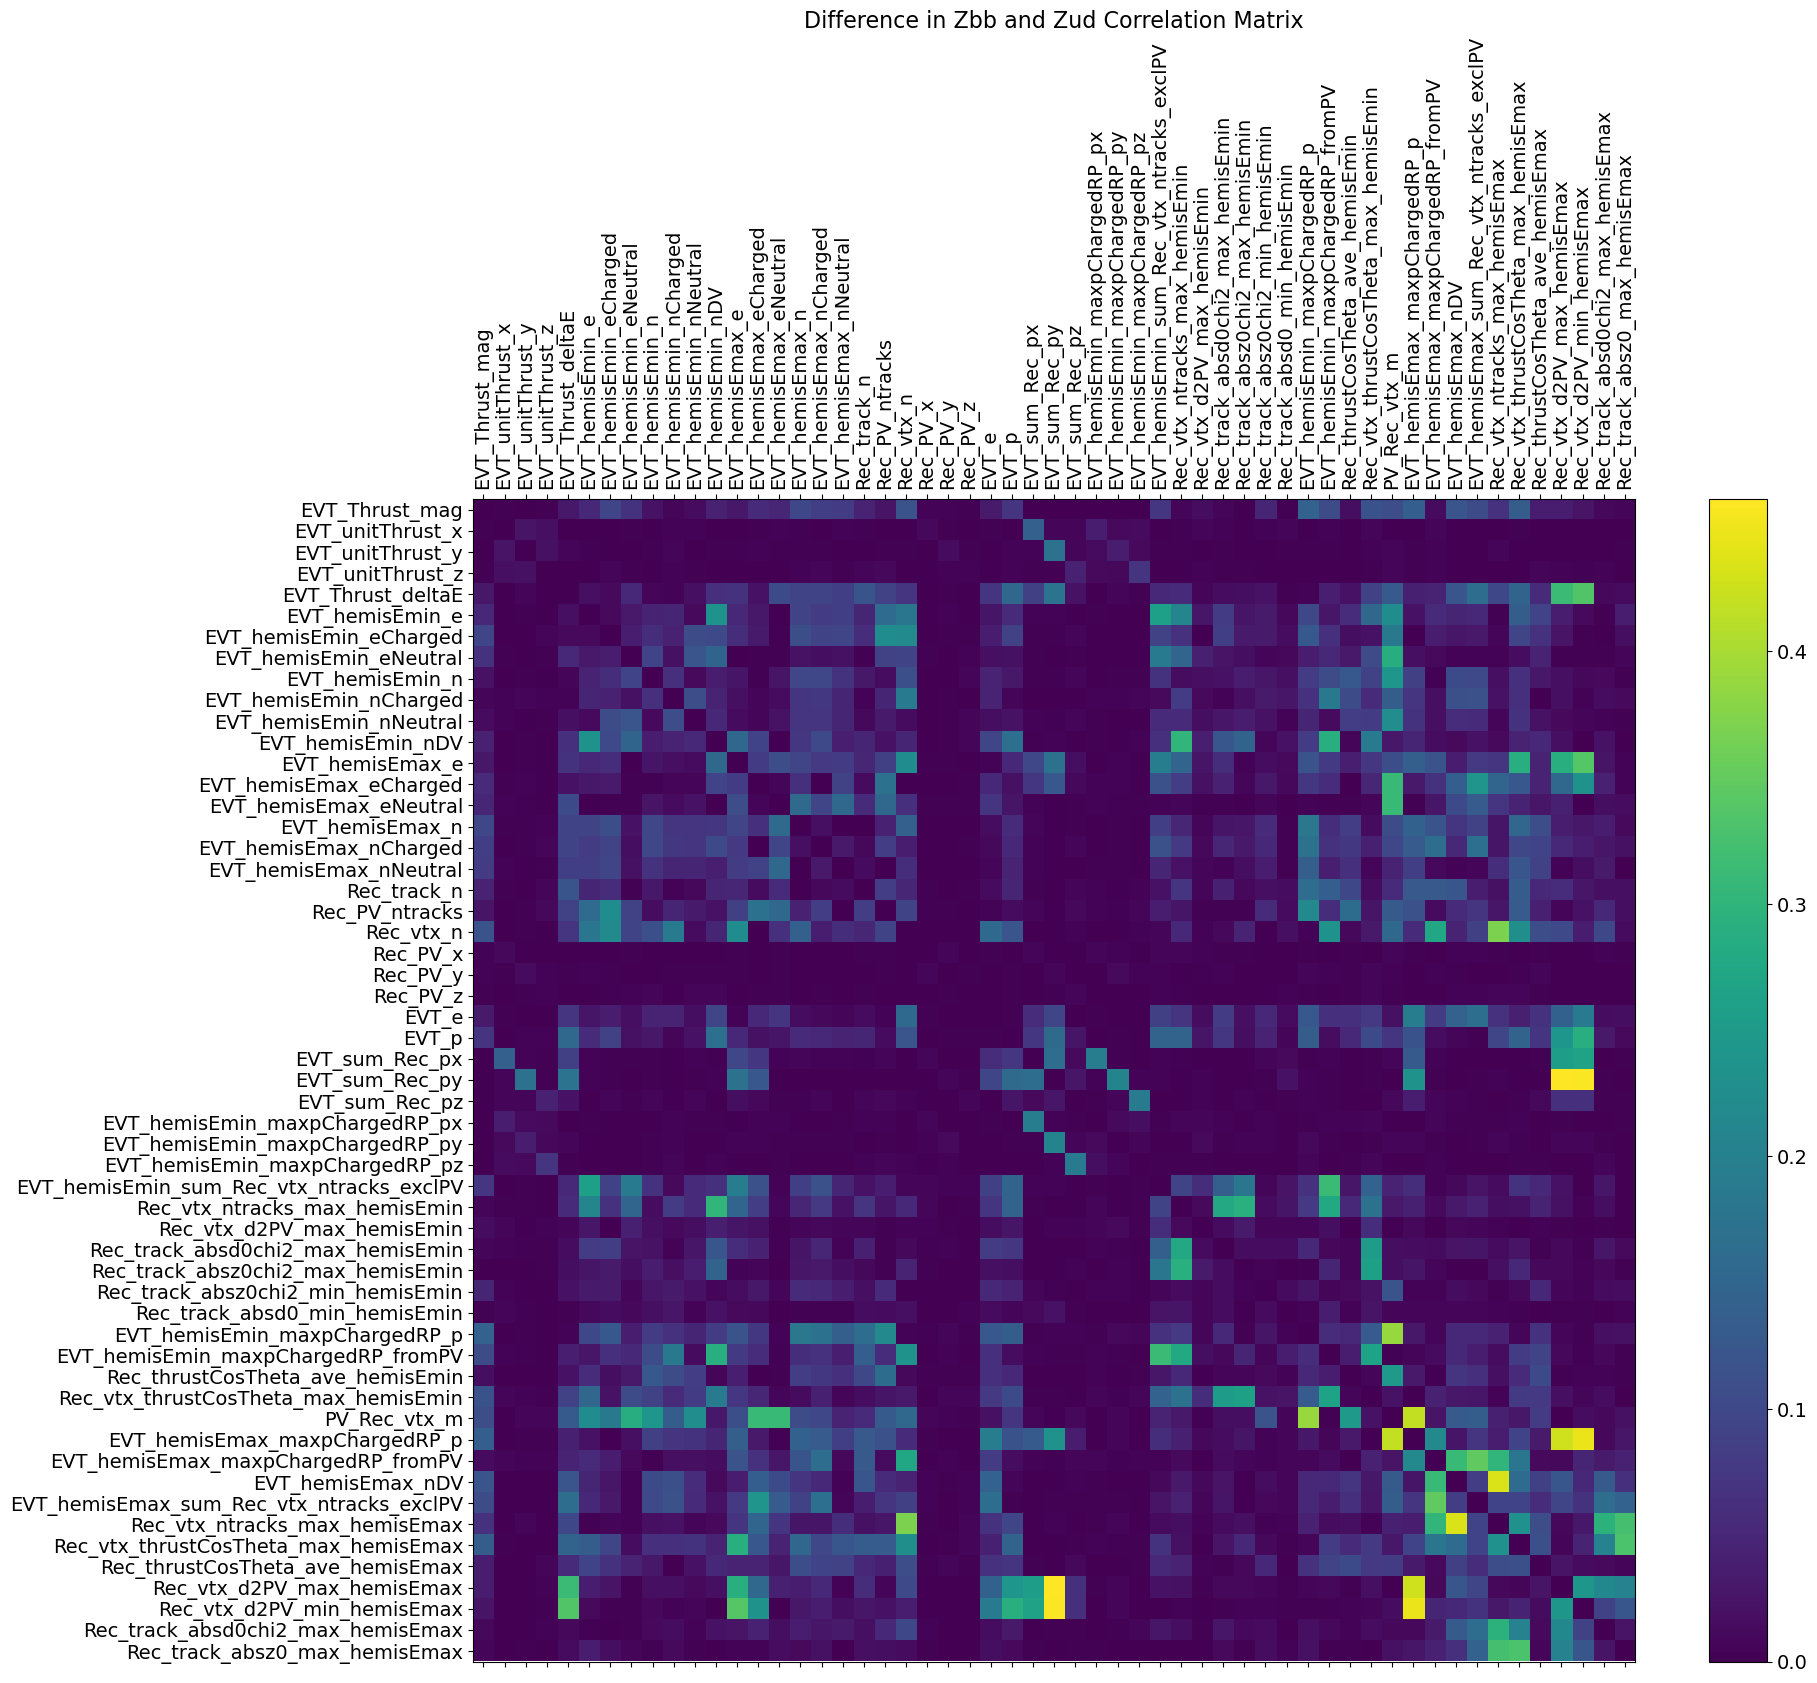

In [23]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
differenece_corr_matrix_udbb = abs( differenece_corr_matrix_Bsbb - differenece_corr_matrix_Bsud)
plt.matshow(differenece_corr_matrix_udbb, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Difference in Zbb and Zud Correlation Matrix', fontsize=16)